<a href="https://colab.research.google.com/github/DanielSmnF/aMineria/blob/main/aCorrelacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objetivo del análisis:
Analizar la relación entre distintas variables del dataset y el monto total de la venta (Amount), utilizando técnicas de análisis exploratorio y correlación, con el fin de identificar variables potencialmente relevantes para la explicación del comportamiento de las ventas.  

Target:  ¿Qué factores influyen en el monto total de una venta realizada en la plataforma de Amazon?  

In [1]:
import pandas as pd

In [12]:
import numpy as np

In [16]:
import matplotlib.pyplot as plt

In [15]:
import seaborn as sns

In [2]:
df = pd.read_csv("amazon_sale.csv", low_memory=False)

**Exploracion del dataset**

In [3]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [8]:
df.shape

(128975, 23)

In [7]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

**Limpieza basica**

In [4]:
df = df.drop(columns=["Unnamed: 22"], errors="ignore")

In [5]:
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Qty"] = pd.to_numeric(df["Qty"], errors="coerce")
df["ship-postal-code"] = pd.to_numeric(df["ship-postal-code"], errors="coerce")

In [ ]:
df = df.dropna(subset=["Amount","Qty"])

In [6]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [10]:
df = df.dropna(subset=["Amount","Qty"])

In [11]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


**Identificacion del Target**

La variable objetivo que tiene sentido analizar es: Amount

Porque representa:

* el valor económico de la venta
* es el resultado final de la transacción

**Identificacion de variables numericas**

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.head()

,index,Qty,Amount,ship-postal-code
0,0,0,647.62,400081.0
1,1,1,406.00,560085.0
2,2,1,329.00,410210.0
3,3,0,753.33,605008.0
4,4,1,574.00,600073.0


**Analisis de correlaciones**

In [14]:
corr_matrix = numeric_df.corr()
corr_matrix

,index,Qty,Amount,ship-postal-code
index,1.000000,0.020216,0.047571,0.005457
Qty,0.020216,1.000000,0.066900,-0.006157
Amount,0.047571,0.066900,1.000000,-0.038195
ship-postal-code,0.005457,-0.006157,-0.038195,1.000000


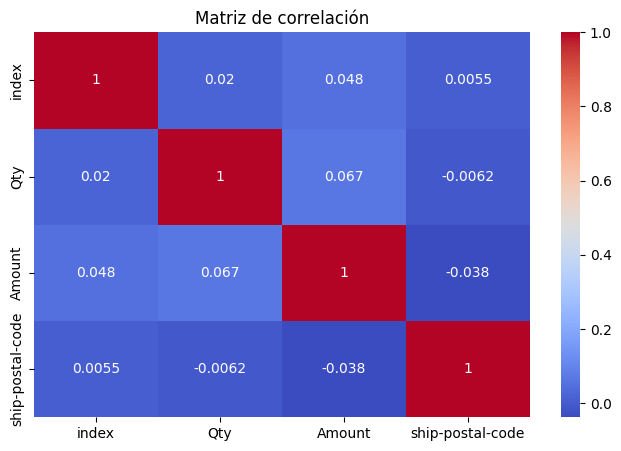

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

**¿Qué variables servirían para un modelo?**

Las variables que pueden servir para un modelo que analice o prediga el Amount  son aquellas que influyen en el valor de la compra como qty, category, size, ship-state y Fulfilment

**Por que una alta correlacion significa que una variable puede ser util**

Una alta correlacion significa que dos variables tienen una relacion fuerte y tienden a cambiar juntas.

Si una variable aumenta o disminuye de forma similar al target, entonces puede ayudar a explicar o predecir su comportamiento.

**Interpretacion critica de resultados**

El analisis muestra que las correlaciones entre las variables numericas y el monto de venta no son muy altas y esto indica que el monto de una venta no depende solo de una variable.

**Seleccion razonada de variables**

Las variables mas relevantes serian Qty, Category, Size, ship-state y Fulfilment, porque pueden influir en el comportamiento de compra y en el monto final de la venta.